<a href="https://colab.research.google.com/github/Thanushrie/Cloud-Ex1/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Dataset Shape: (1000, 31)
   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  1stFlrSF  2ndFlrSF  \
0   1            7       3540           1         1683      1432      1231   
1   2            4       2139           2          123       999         7   
2   3            8       1327           4         2048      2338       701   
3   4            5       3230           4          967       851       528   
4   5            7       3551           0          854       704       601   

   FullBath  HalfBath  YearBuilt  ...  BsmtFinSF1 BsmtUnfSF BedroomAbvGr  \
0         3         2       1902  ...      1019.0      1404            3   
1         0         1       1945  ...       916.0        34            1   
2         0         1       1954  ...       438.0       406            1   
3         0         0       1974  ...      1015.0       313            4   
4         3         2       1987  ...      1080.0       815            2   

  KitchenAbvGr TotRmsAbvGrd Fireplaces GarageAre

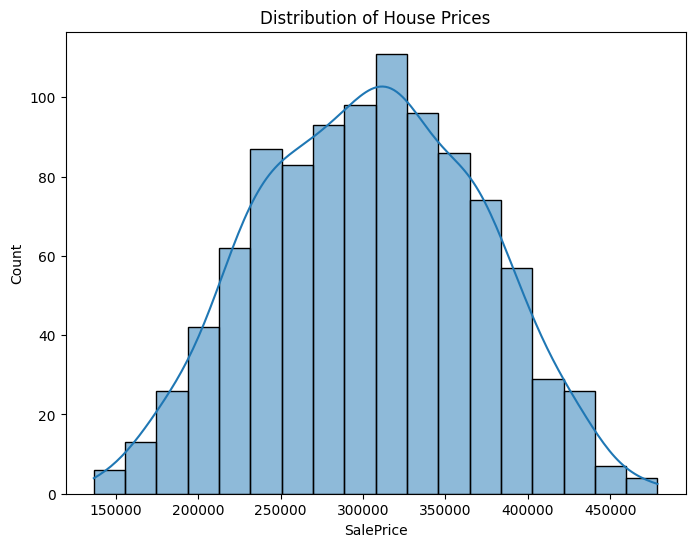

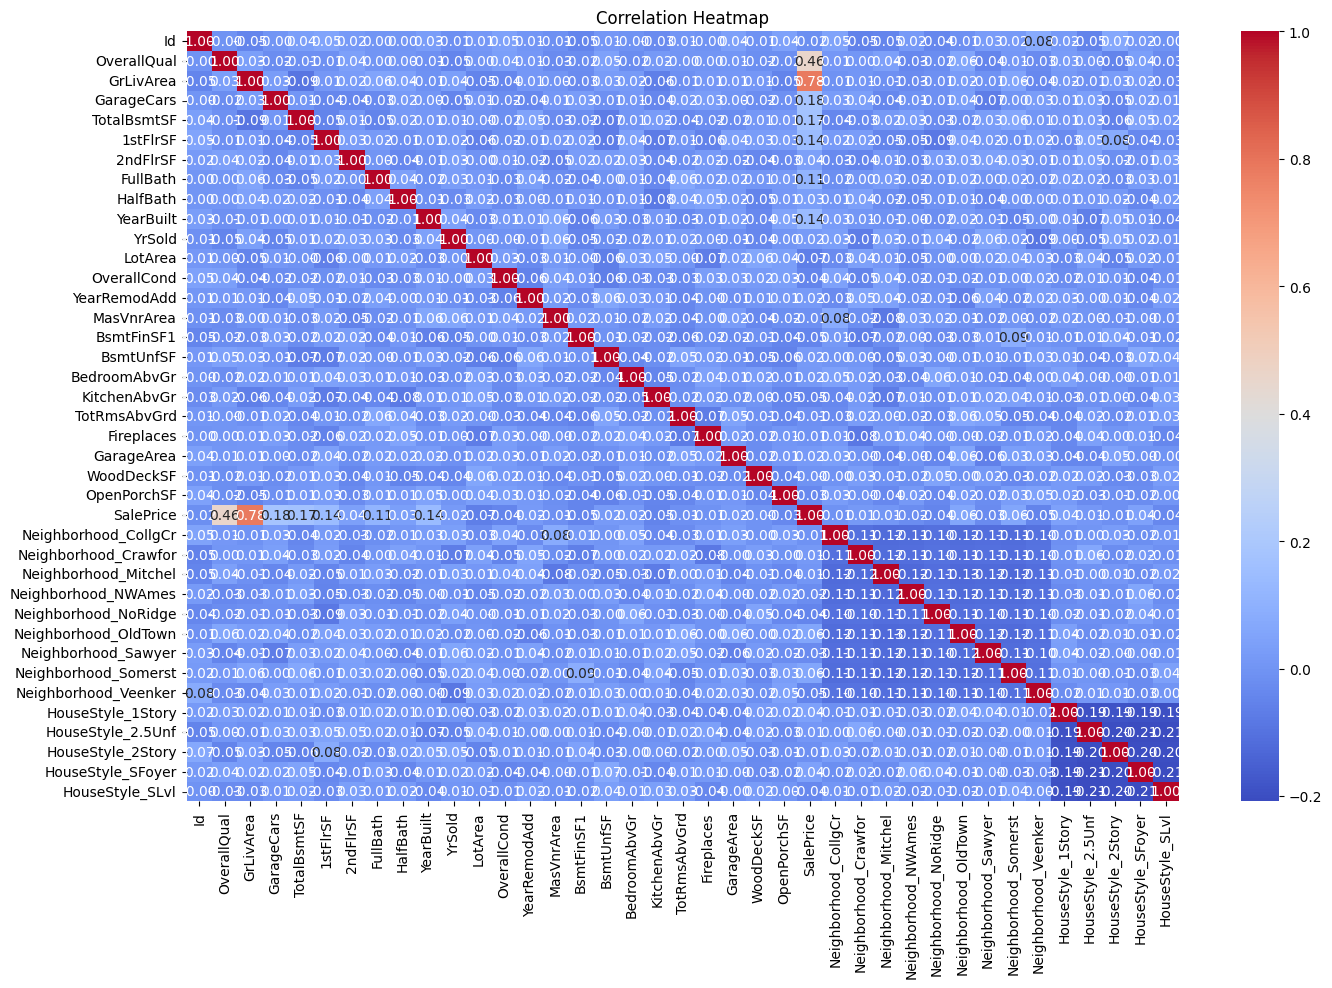

Top correlated features:
 SalePrice               1.000000
GrLivArea               0.783309
OverallQual             0.455939
GarageCars              0.179085
TotalBsmtSF             0.173507
1stFlrSF                0.142465
YearBuilt               0.137380
FullBath                0.111341
Neighborhood_OldTown    0.058283
Neighborhood_Somerst    0.057392
Name: SalePrice, dtype: float64
RMSE: 17326.00
R² Score: 0.9206


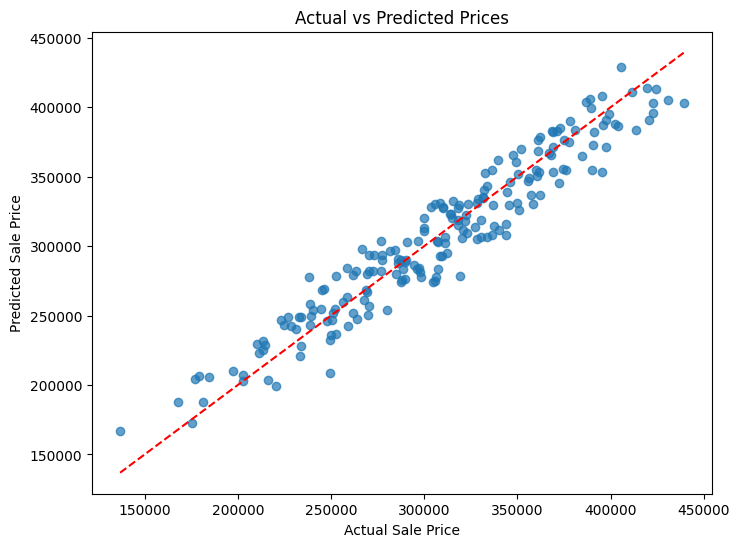

In [2]:
data = pd.read_csv('house_prices.csv') # replace with actual path
print("Dataset Shape:", data.shape)
print(data.head())
# 3. Initial Data Analysis
print(data.info())
print(data.describe())

missing = data.isnull().sum()
missing = missing[missing > 0]
print("Missing Values:\n", missing)
# Drop columns with too many missing values (optional)
data = data.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], axis=1)
# Fill remaining missing values
data.fillna(data.median(numeric_only=True), inplace=True)

# Encoding categorical data (simple encoding for example) - Moved before EDA that uses numerical correlation
data = pd.get_dummies(data, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

# 5. Exploratory Data Analysis (EDA)
# Histogram of SalePrice
plt.figure(figsize=(8, 6))
sns.histplot(data['SalePrice'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()
# Correlation heatmap
plt.figure(figsize=(16, 10))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# Top correlated features with SalePrice
top_corr = corr['SalePrice'].sort_values(ascending=False).head(10)
print("Top correlated features:\n", top_corr)
# 6. Feature Engineering
# Creating new features
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
data['TotalBath'] = data['FullBath'] + 0.5 * data['HalfBath']
data['Age'] = data['YrSold'] - data['YearBuilt']
# 7. Feature Selection
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalSF', 'TotalBath', 'Age']
X = data[features]
y = data['SalePrice']
# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 9. Model Training
model = LinearRegression()
model.fit(X_train, y_train)
# 10. Prediction
y_pred = model.predict(X_test)
# 11. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
# 12. Visualization of Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Prices')
plt.show()